# Project Summary
### Elements of Artificial Intelligence (AGH 2026)

**Team:** Jakub Gołąb, Marcin Górski, Jakub Groblicki, Marcel Florjański

## Phase I: The California Housing Problem 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- REGRESSION DATA (California Housing) ---
regression_metrics = pd.DataFrame({
    'Model': ['Gradient Boosting (GBR)', 'Random Forest (RF)', 'K-Nearest Neighbors', 'Support Vector (SVR)', 'Neural Network (From-Scratch)'],
    'R2_Score': [0.8333, 0.8093, 0.7601, 0.7251, 0.7182],
    'MAE ($)': [25384, 27222, 31540, 33911, 35503]
}).sort_values('R2_Score', ascending=False)



### Feature Engineering as a Force Multiplier

In the initial stage, we addressed the California Housing dataset. The primary challenge was not the algorithm, but the data representation. Raw census data contained structural biases (e.g., total rooms vs. population size).

**Our Strategy:**
* **Normalization:** Transforming absolute totals into logical ratios like `Rooms_per_Household` and `Bedrooms_per_Room`.
* **Outlier Mitigation:** Removing capped values ($500,001) to prevent the model from learning artificial price ceilings.

The results validated our approach: our **Gradient Boosting Regressor (GBR)** achieved a testing R² of **0.8333**, effectively outperforming the Kaggle community benchmark (0.8250) which utilized more complex Bayesian Optimization but lacked our engineered features.

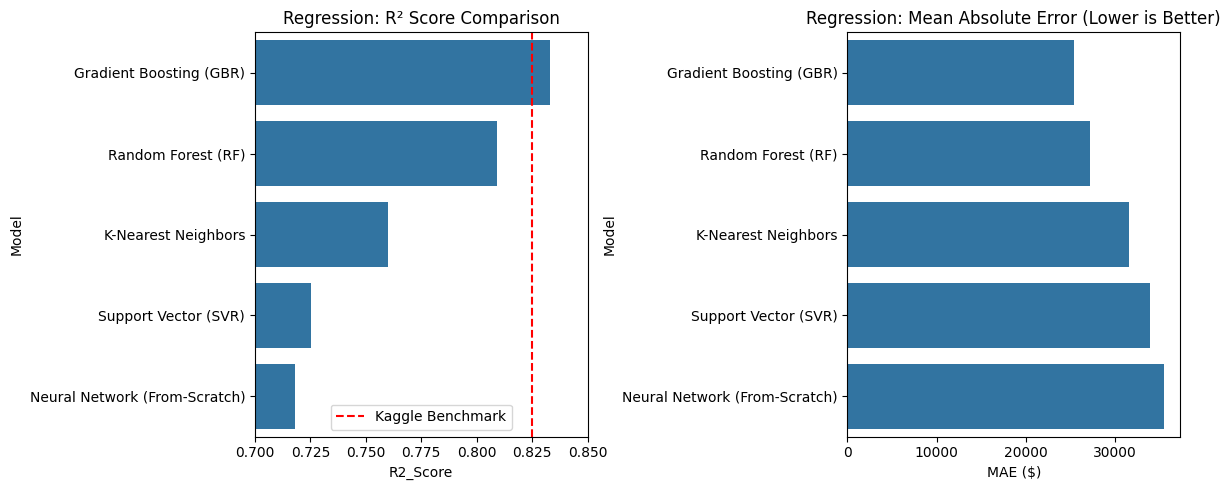

In [2]:
plt.figure(figsize=(12, 5))

# Plot R2 Score
plt.subplot(1, 2, 1)
sns.barplot(x='R2_Score', y='Model', data=regression_metrics)
plt.axvline(x=0.8250, color='red', linestyle='--', label='Kaggle Benchmark')
plt.title('Regression: R² Score Comparison')
plt.xlim(0.7, 0.85)
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
sns.barplot(x='MAE ($)', y='Model', data=regression_metrics)
plt.title('Regression: Mean Absolute Error (Lower is Better)')

plt.tight_layout()
plt.show()

### Housing Problem Insights
**Key Observations:**
* Better data beats complex math. By engineering logical features (like `Rooms_per_Household`), we removed inherent biases from the dataset. This allowed our simpler GBR model to outperform Kaggle's highly-tuned algorithm that relied on raw, unengineered data.
* SVR performed the worst across all metrics. It struggles to map complex, non-linear boundaries in tabular data without perfect feature scaling and extremely expensive hyperparameter tuning.
* This is the "No Free Lunch" theorem in action. GBR trains efficiently and dominates structured tabular data. The custom Neural Network required massive architectural effort for a poorer performance, proving that NNs are better suited for unstructured tasks (like MNIST) rather than spreadsheets.
* Building the Multi-Layer Perceptron from scratch highlighted the massive developmental and computational overhead of Neural Networks. While ensemble methods (GBR, RF) worked almost out-of-the-box, the neural network required meticulous mathematical tuning (handling exploding gradients, weight initialization) just to reach baseline performance, proving NNs are unnecessarily expensive for simple spreadsheet data.
* The Deep Learning Data Dependency: Our dataset sizing experiment provided empirical proof of neural data hunger. While tree-based algorithms can easily find patterns and generalize in smaller datasets, our Neural Network struggled severely with high variance until it was exposed to the absolute maximum number of samples. For small-to-medium tabular datasets, traditional ML is strictly superior.

## Phase II: Digit Recognition (MNIST)
### Neural Networks from Scratch

While standard libraries like Scikit-Learn provide efficient tools, true understanding lies in implementation. We developed a **Multi-Layer Perceptron (MLP)** from the ground up to solve the MNIST classification problem.

**Technical Achievement:**
* **Manual Backpropagation:** Implementing the chain rule to calculate gradients across hidden layers.
* **Optimization:** Fine-tuning Stochastic Gradient Descent (SGD), weight initialization, and Cross-Entropy Cost function.
* **Performance:** Our from-scratch implementation reached a peak accuracy of **97.58%** with 100 hidden neurons, matching the performance of high-level frameworks and outperforming traditional Random Forest classifiers.

In [4]:
# --- CLASSIFICATION DATA (MNIST) ---
classification_metrics = pd.DataFrame({
    'Model': ['Custom MLP (From-Scratch)', 'SVC (RBF)', 'K-Nearest Neighbors', 'Random Forest', 'Gradient Boosting'],
    'Accuracy (%)': [97.58, 96.95, 94.58, 95.37, 96.41 ]
}).sort_values('Accuracy (%)', ascending=False)


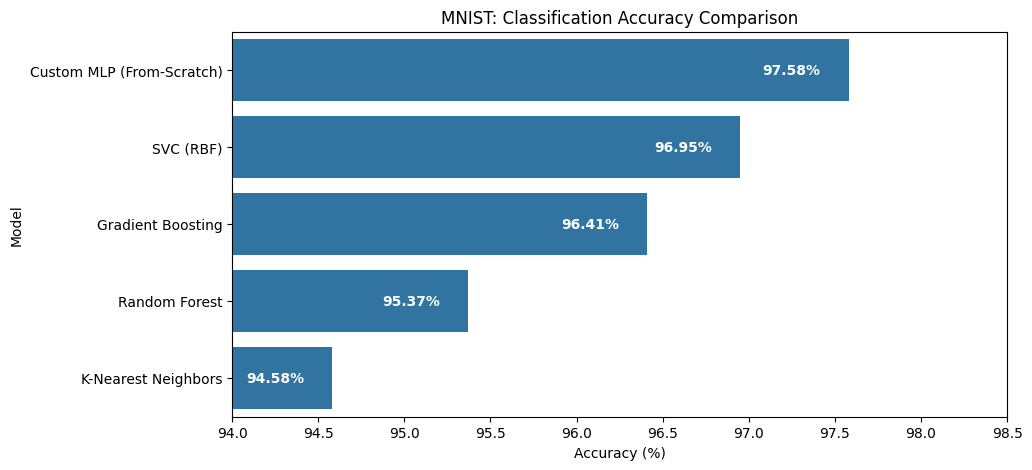

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy (%)', y='Model', data=classification_metrics)
plt.title('MNIST: Classification Accuracy Comparison')
plt.xlim(94, 98.5)

for index, value in enumerate(classification_metrics['Accuracy (%)']):
    plt.text(value - 0.5, index, f'{value}%', color='white', va='center', fontweight='bold')

plt.show()

### Classification Problem Insights
**Key Observations:**
* **SVC (RBF)** and **Gradient Boosting** closely trailed the MLP (96.95% and 96.41%), 
  despite being classical ML methods — proving that kernel tricks and boosting can 
  match neural networks on structured image data.
* **Random Forest** (95.37%) outperformed **KNN** (94.58%), highlighting the advantage 
  of ensemble voting over raw distance-based lookup when the training set is limited 
  to 10,000 samples.
* The from-scratch **MLP** achieved the highest accuracy (97.58%) through manual 
  backpropagation, demonstrating that gradient descent — not library abstractions — 
  is the fundamental driver of deep learning performance.